# Test TensorFlow Simulation Engine

Quick test to verify the TF simulation engine works and produces reasonable results.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from simulation_engine_tf.commands import RunSimulationCommandTF
from simulation_engine_tf.common.types import SimulationPortfolioWeights, CashFlow
from simulation_engine_tf.common.enums import SimulationType, SimulationStepType, InterpolationMethod


2025-10-30 17:32:52.709348: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/oliver/Documents/AdviceTools/.venv/lib/python3.12/site-packages/pydantic/_internal/_config.py:383: UserWarning: Valid config keys have changed in V2:
* 'allow_population_by_field_name' has been renamed to 'validate_by_name'
* 'validate_all' has been renamed to 'validate_default'
  warnings.warn(message, UserWarning)


In [2]:
# Test parameters
n_sims = 5000
end_step = 60
initial_wealth = 100000


weights = [
    SimulationPortfolioWeights(step=0, stocks=0.9, bonds=0.08),
    SimulationPortfolioWeights(step=40, stocks=0.3, bonds=0.68)
]

cash_flows = [
    CashFlow(step=0, value=25000), # $10k/year
    CashFlow(step=30, value=-40000)

]



In [3]:

command = RunSimulationCommandTF(
    number_of_simulations=n_sims,
    end_step=end_step,
    weights=weights,
    savings_rates=cash_flows,
    initial_wealth=initial_wealth,
    simulation_type=SimulationType.CHOLESKY,
    step_size=SimulationStepType.ANNUAL,
    weights_interpolation=InterpolationMethod.FFILL,
    savings_rate_interpolation=InterpolationMethod.FFILL
)

result = command.handle()
print(f"Simulation completed in {result.simulation_time:.3f} seconds")
print(f"Time per simulation: {result.simulation_time_per_path:.6f} seconds")


/Users/oliver/Documents/AdviceTools/simulation_engine_tf/commands.py:74: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base_sim_data["transactions"] = base_sim_data["transactions"].fillna(0)
/Users/oliver/Documents/AdviceTools/simulation_engine_tf/commands.py:95: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  exp_return['Expected Return'] = exp_return['overrides'].combine_first(exp_return['Expected Return'])


Simulation completed in 0.479 seconds
Time per simulation: 0.000096 seconds


In [4]:
# Use the TF-native handle to keep tensors (no DTO/NumPy conversion)
import tensorflow as tf
sim_data_tf = command.handle_tf()  # tf.Tensor [n, s+1]
print("TF simulation tensor:", type(sim_data_tf), sim_data_tf.shape)

# Example: compute a simple objective directly on the tensor
final_wealth_tf = tf.cast(sim_data_tf[:, -1], tf.float64)
objective_tf = -tf.reduce_mean(final_wealth_tf)
print("Objective (tensor):", float(objective_tf.numpy()))


TF simulation tensor: <class 'tensorflow.python.framework.ops.EagerTensor'> (5000, 61)
Objective (tensor): -100339851.24641319


/Users/oliver/Documents/AdviceTools/simulation_engine_tf/commands.py:179: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  exp_return['Expected Return'] = exp_return['overrides'].combine_first(exp_return['Expected Return'])


In [4]:
import tensorflow as tf

# Inspect the TF strategy inputs
st = command.simulation_strategy

print("weights shape:", st.weights.shape, "first row:", st.weights.numpy()[0])
print("cashflows shape:", st.cashflows.shape, "first 5:", st.cashflows.numpy()[:5])
print("transactions shape:", st.transactions.shape, "first 5:", st.transactions.numpy()[:5])
print("time_steps shape:", st.time_steps.shape, "first 5:", st.time_steps.numpy()[:5])

rets = st.simulated_returns
print("simulated_returns shape:", rets.shape)
print("simulated_returns mean per-asset:", tf.reduce_mean(rets, axis=[0,1]).numpy())
print("simulated_returns std per-asset:", tf.math.reduce_std(rets, axis=[0,1]).numpy())

# Single-step sanity check for step 0
w0 = st.weights.numpy()[0]
r0 = rets.numpy()[:,0,:]
dt0 = float(st.time_steps.numpy()[1] - st.time_steps.numpy()[0])
growth0 = (w0 * (1.0 + r0) ** dt0).sum(axis=1)
print("growth0 min/mean/max:", growth0.min(), growth0.mean(), growth0.max())

weights shape: (60, 3) first row: [0.08 0.9  0.02]
cashflows shape: (60,) first 5: [25000. 25000. 25000. 25000. 25000.]
transactions shape: (60,) first 5: [0. 0. 0. 0. 0.]
time_steps shape: (61,) first 5: [0. 1. 2. 3. 4.]
simulated_returns shape: (5000, 60, 3)
simulated_returns mean per-asset: [0.07796657 0.11062638 0.06404124]
simulated_returns std per-asset: [0.06002462 0.20452893 0.05258558]
growth0 min/mean/max: 0.3632385520415463 1.1045343213051322 1.8046225002584733


In [5]:
# Check results
sim_data = result.nominal.simulation_data
print(f"Simulation data shape: {sim_data.shape}")
print(f"Final wealth stats:")
print(f"  Mean: ${result.nominal.final_mean:,.0f}")
print(f"  Median: ${result.nominal.final_median:,.0f}")
print(f"  Std: ${result.nominal.final_std:,.0f}")
print(f"  Min: ${result.nominal.final_min:,.0f}")
print(f"  Max: ${result.nominal.final_max:,.0f}")
print(f"Destitution risk: {result.destitution[-1]:.1%}")


Simulation data shape: (5000, 61)
Final wealth stats:
  Mean: $99,163,390
  Median: $56,599,424
  Std: $135,197,551
  Min: $0
  Max: $2,137,472,103
Destitution risk: 3.5%


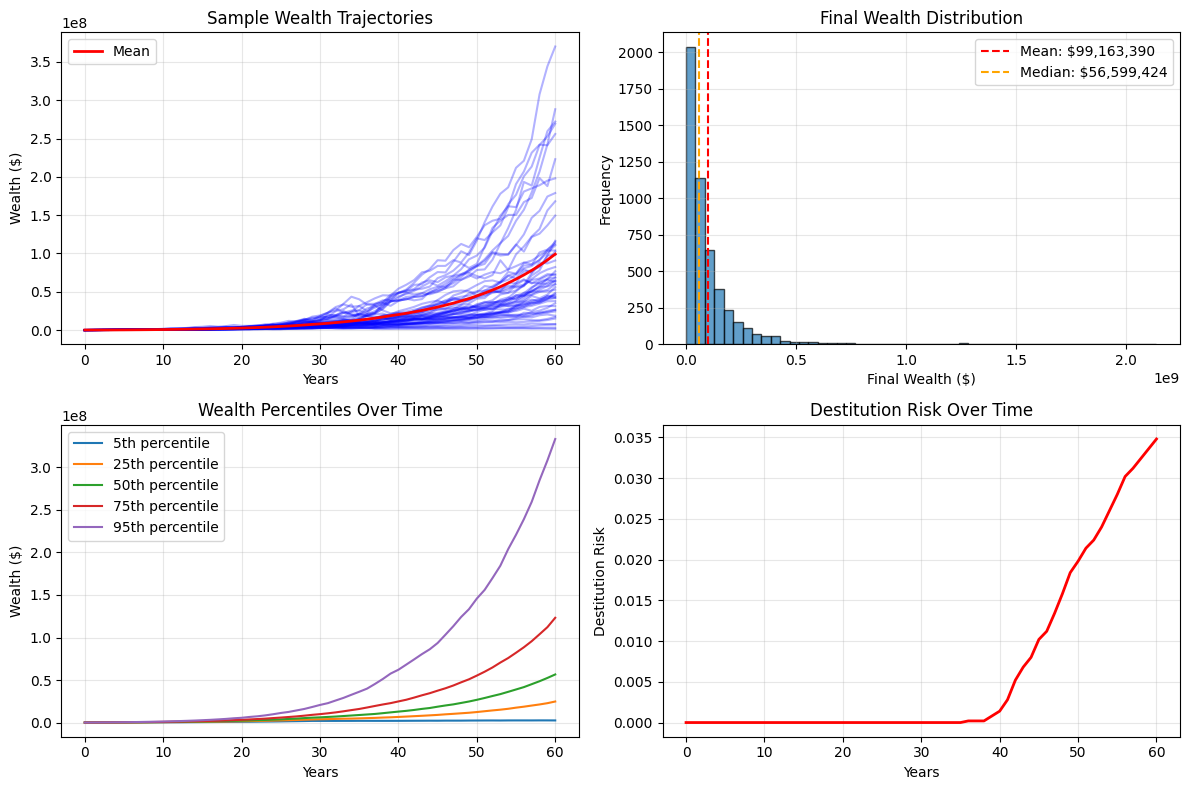

In [6]:
# Plot wealth trajectories
plt.figure(figsize=(12, 8))

# Sample of trajectories
sample_size = 50
sample_indices = np.random.choice(n_sims, sample_size, replace=False)

plt.subplot(2, 2, 1)
for i in sample_indices:
    plt.plot(sim_data[i, :], alpha=0.3, color='blue')
plt.plot(result.nominal.mean, color='red', linewidth=2, label='Mean')
plt.title('Sample Wealth Trajectories')
plt.xlabel('Years')
plt.ylabel('Wealth ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# Final wealth distribution
plt.subplot(2, 2, 2)
final_wealth = sim_data[:, -1]
plt.hist(final_wealth, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(result.nominal.final_mean, color='red', linestyle='--', label=f'Mean: ${result.nominal.final_mean:,.0f}')
plt.axvline(result.nominal.final_median, color='orange', linestyle='--', label=f'Median: ${result.nominal.final_median:,.0f}')
plt.title('Final Wealth Distribution')
plt.xlabel('Final Wealth ($)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

# Percentiles over time
plt.subplot(2, 2, 3)
percentiles = [5, 25, 50, 75, 95]
for p in percentiles:
    plt.plot(result.nominal.percentiles[p], label=f'{p}th percentile')
plt.title('Wealth Percentiles Over Time')
plt.xlabel('Years')
plt.ylabel('Wealth ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# Destitution risk over time
plt.subplot(2, 2, 4)
plt.plot(result.destitution, color='red', linewidth=2)
plt.title('Destitution Risk Over Time')
plt.xlabel('Years')
plt.ylabel('Destitution Risk')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
# Gradient check using handle_tf() inputs but TF-built weights
import tensorflow as tf
from simulation_engine_tf.calcs import simulate_wealth_tf

# Build a small decision vector (stocks share per step)
# Length matches s = number of steps in the command
s = int(command.base_simulation_data.shape[0]) - 1
allocations = tf.Variable(tf.cast(tf.linspace(0.9, 0.5, s), tf.float64))

# Get tensors from the strategy (keeps graph intact)
st = command.simulation_strategy
rets = st.simulated_returns    # [n, s, k] tf.float64
cash = st.cashflows            # [s]
txns = st.transactions         # [s]
tsteps = st.time_steps         # [s+1]

# Build weights from allocations to match asset order
cols = []
for a in st.assets:
    a_l = a.lower()
    if a_l == "stocks":
        cols.append(allocations)
    elif a_l == "bonds":
        cols.append(1.0 - allocations)
    else:  # cash/other assets not controlled in this check
        cols.append(tf.zeros_like(allocations))
weights_tf = tf.stack(cols, axis=1)  # [s, k]

with tf.GradientTape() as tape:
    tape.watch(allocations)
    wealth = simulate_wealth_tf(
        rets,
        weights_tf,
        initial_wealth=command.initial_wealth,
        cashflows=cash,
        transactions=txns,
        inflation=command.inflation,
        time_steps=tsteps,
    )  # [n, s+1]
    final_wealth = wealth[:, -1]
    objective = -tf.reduce_mean(final_wealth)

grads = tape.gradient(objective, allocations)
print("Objective:", float(objective.numpy()))
print("Gradients is None:", grads is None)
if grads is not None:
    print("Gradients (first 5):", grads.numpy()[:5])


Objective: -107622230.79381716
Gradients is None: True


In [14]:
import tensorflow as tf
from simulation_engine_tf.calcs import simulate_wealth_tf

# allocations as float64 so no cast barriers
allocations = tf.Variable([0.9, 0.8, 0.7, 0.6, 0.5], dtype=tf.float64)
init_w = 100000

cmd = RunSimulationCommandTF(
    number_of_simulations=1000,
    end_step=int(allocations.shape[0]) - 1,
    weights=[SimulationPortfolioWeights(step=float(i), stocks=0.5, bonds=0.5) for i in range(int(allocations.shape[0]))],
    initial_wealth=init_w,
)
st = cmd.simulation_strategy
rets, cash, txns, tsteps = st.simulated_returns, st.cashflows, st.transactions, st.time_steps
s = int(tsteps.shape[0]) - 1

# Build weights matching asset order, no dtype casts
alloc_s = allocations[:s]
cols = []
for a in st.assets:
    a_l = a.lower()
    if a_l == "stocks": cols.append(alloc_s)
    elif a_l == "bonds": cols.append(1.0 - alloc_s)
    else: cols.append(tf.zeros_like(alloc_s))
weights_tf = tf.stack(cols, axis=1)  # [s, k]

with tf.GradientTape() as tape:
    wealth = simulate_wealth_tf(rets, weights_tf, init_w, cash, txns, cmd.inflation, tsteps)  # float64 throughout
    objective = -tf.reduce_mean(wealth[:, -1])  # float64

grads = tape.gradient(objective, allocations)
print("Objective:", float(objective.numpy()))
print("Gradients:", None if grads is None else grads.numpy())

Objective: -146190.47109894067
Gradients: None


/Users/oliver/Documents/AdviceTools/simulation_engine_tf/commands.py:74: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base_sim_data["transactions"] = base_sim_data["transactions"].fillna(0)


## Test Results

This test verifies:
1. **Basic functionality**: TF simulation runs without errors
2. **Reasonable results**: Wealth trajectories look sensible
3. **Gradient computation**: The key test - can we compute gradients through the simulation?

If the gradient test passes, we can integrate this into the optimization notebook!
